In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import FancyBboxPatch
pd.set_option('display.float_format', '{:,.1f}'.format)

In [10]:
df = pd.read_csv('data/airport_traffic_merged.csv')

In [11]:
selected_airports = (
    df.groupby(["APT_NAME"])["FLT_TOT_1"].sum()
    .reset_index()
    .sort_values("FLT_TOT_1", ascending=False)
    .head(20)
)

[]

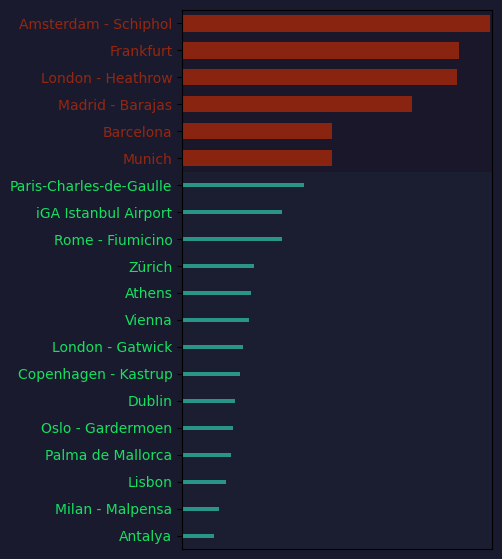

In [12]:
# Black hat
fig, ax = plt.subplots(figsize=(4, 7))

# Sfondo scuro
fig.set_facecolor("#1a1a2e")
ax.set_facecolor("#1a1a2e")

labels = [row.APT_NAME for _, row in selected_airports.iterrows()]
values = (selected_airports["FLT_TOT_1"] / 1e6).values
colors = ["#C42E08BB" if i < 6 else "#2A9D8F" for i in range(len(selected_airports))]

# Crea le barre una per una con altezze diverse
for i, (label, val) in enumerate(zip(labels, values)):
    h = 0.6 if i < 6 else 0.15
    ax.barh(label, val, color=colors[i], edgecolor="none", height=h)

#imposta colori diversi per le etichette
for i, label in enumerate(ax.get_yticklabels()):
    if i < 6:
        label.set_color("#C22C06BB")
    else:
        label.set_color("#16E060")


# Sfondo per i primi 5 elementi
ax.axhspan(-0.5, 5.5, facecolor="#110501", alpha=0.1)

# Sfondo per gli altri
ax.axhspan(5.5, len(selected_airports) - 0.5, facecolor="#264653", alpha=0.1)        

#mette linea verticale
#ax.axvline(x = 1.86, color = 'red', linestyle= '--')


#ax.set_xlim(1.1, auto = False, emit = False)
ax.set_ylim(-0.5, len(selected_airports) - 0.5)
ax.invert_yaxis()

ax.set_xlim( 1.1, 3)  # imposta il range che viene visualizzato sulle x
ax.set_xticks([]) # imposta gli elementi della scala che si possono mettere sulle x



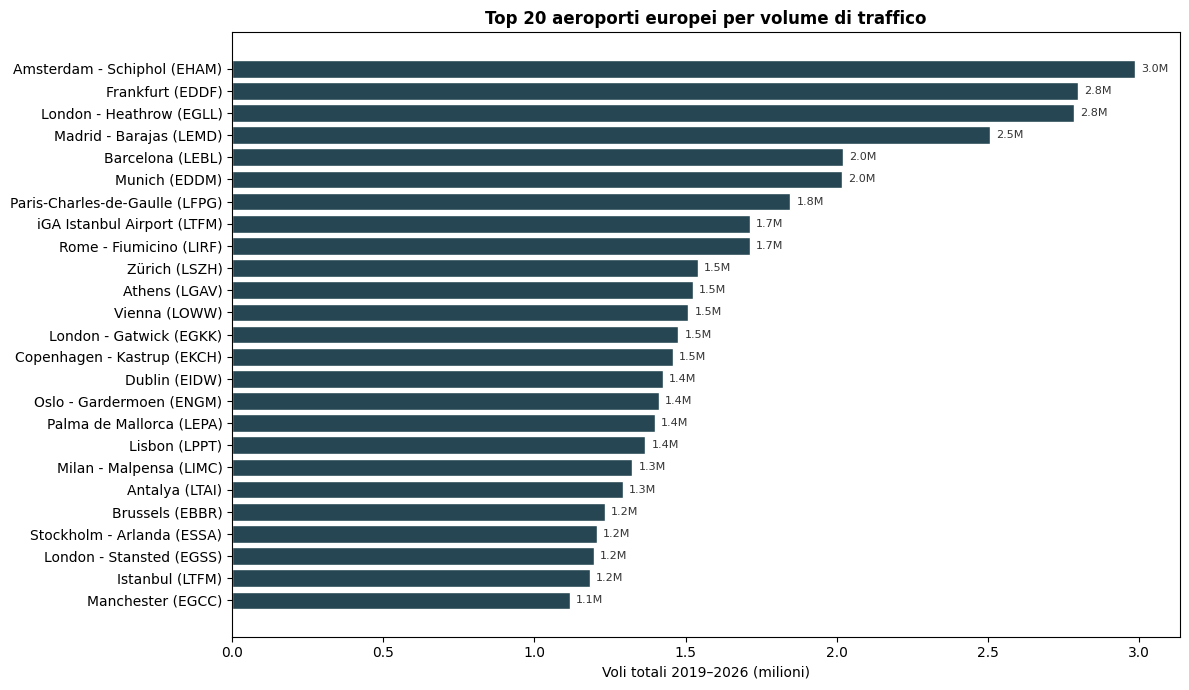

[Salvato] eda_apt_04_top20.png


In [ ]:
top20 = (
    df.groupby(["APT_ICAO","APT_NAME"])["FLT_TOT_1"].sum()
    .reset_index()
    .sort_values("FLT_TOT_1", ascending=False)
    .head(25)
)


fig, ax = plt.subplots(figsize=(12, 7))
labels = [f"{row.APT_NAME} ({row.APT_ICAO})" for _, row in top20.iterrows()]
bars = ax.barh(labels, top20["FLT_TOT_1"] / 1e6,
               color="#264653", edgecolor="white")
ax.invert_yaxis()
ax.set_xlabel("Voli totali 2019–2026 (milioni)")
ax.set_title("Top 20 aeroporti europei per volume di traffico", fontweight="bold")

for bar, val in zip(bars, top20["FLT_TOT_1"]):
    ax.text(bar.get_width() + 0.02, bar.get_y() + bar.get_height()/2,
            f"{val/1e6:.1f}M", va="center", fontsize=8, color="#333")

plt.tight_layout()
#plt.savefig("eda_apt_04_top20.png")
plt.show()
print("[Salvato] eda_apt_04_top20.png")

---
---
---



In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import FancyBboxPatch
pd.set_option('display.float_format', '{:,.1f}'.format)

In [ ]:
df_state = pd.read_csv('data/clean/emission_state_clean.csv')

In [8]:
CODE2NAME = {
    "AL":"Albania","AM":"Armenia","AT":"Austria","AZ":"Azerbaijan",
    "BA":"Bosnia","BE":"Belgium","BG":"Bulgaria","CH":"Switzerland",
    "CY":"Cyprus","CZ":"Czechia","DE":"Germany","DK":"Denmark",
    "EE":"Estonia","ES":"Spain","FI":"Finland","FR":"France",
    "GB":"UK","GE":"Georgia","GR":"Greece","HR":"Croatia",
    "HU":"Hungary","IE":"Ireland","IL":"Israel","IS":"Iceland",
    "IT":"Italy","LT":"Lithuania","LU":"Luxembourg","LV":"Latvia",
    "MA":"Morocco","MD":"Moldova","ME":"Montenegro","MK":"N.Macedonia",
    "MT":"Malta","NL":"Netherlands","NO":"Norway","PL":"Poland",
    "PT - Lisbon FIR":"Portugal","PT - Santa Maria FIR":"PT Azores",
    "RO":"Romania","RS":"Serbia","SE":"Sweden","SI":"Slovenia",
    "SK":"Slovakia","TR":"Turkey","UA":"Ukraine"
}

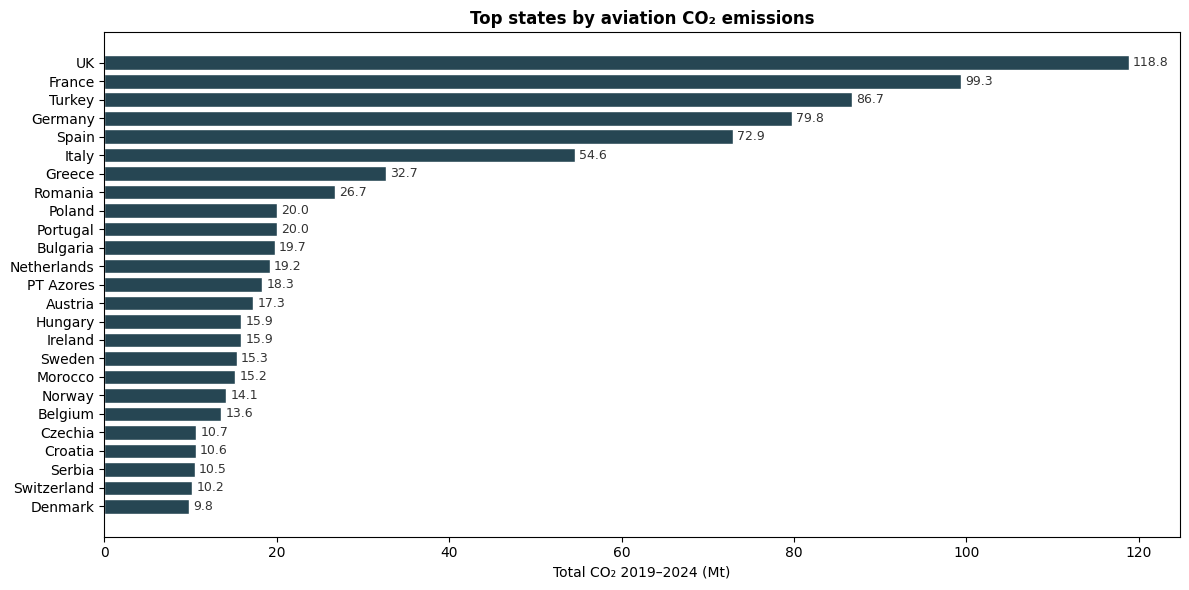

[Saved] eda_em_06_top_states.png


In [9]:
state_tot = (
    df_state.groupby("AREA")["CO2_KG"].sum()
    .reset_index()
    .sort_values("CO2_KG", ascending=False)
    .head(25)
)
state_tot["name"] = state_tot["AREA"].map(CODE2NAME).fillna(state_tot["AREA"])

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.barh(state_tot["name"], state_tot["CO2_KG"] / 1e9,
               color="#264653", edgecolor="white")
ax.invert_yaxis()
ax.set_xlabel("Total CO\u2082 2019\u20132024 (Mt)")
ax.set_title("Top states by aviation CO\u2082 emissions", fontweight="bold")

# Annotate values
for bar, val in zip(bars, state_tot["CO2_KG"]):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
            f"{val/1e9:.1f}", va="center", fontsize=9, color="#333")

plt.tight_layout()
plt.savefig("eda_em_06_top_states.png")
plt.show()
print("[Saved] eda_em_06_top_states.png")

/var/folders/jy/4b2lm4512fj3l_x07qr_5v_r0000gn/T/ipykernel_2833/2551823421.py:67: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.04, 1, 0.95])


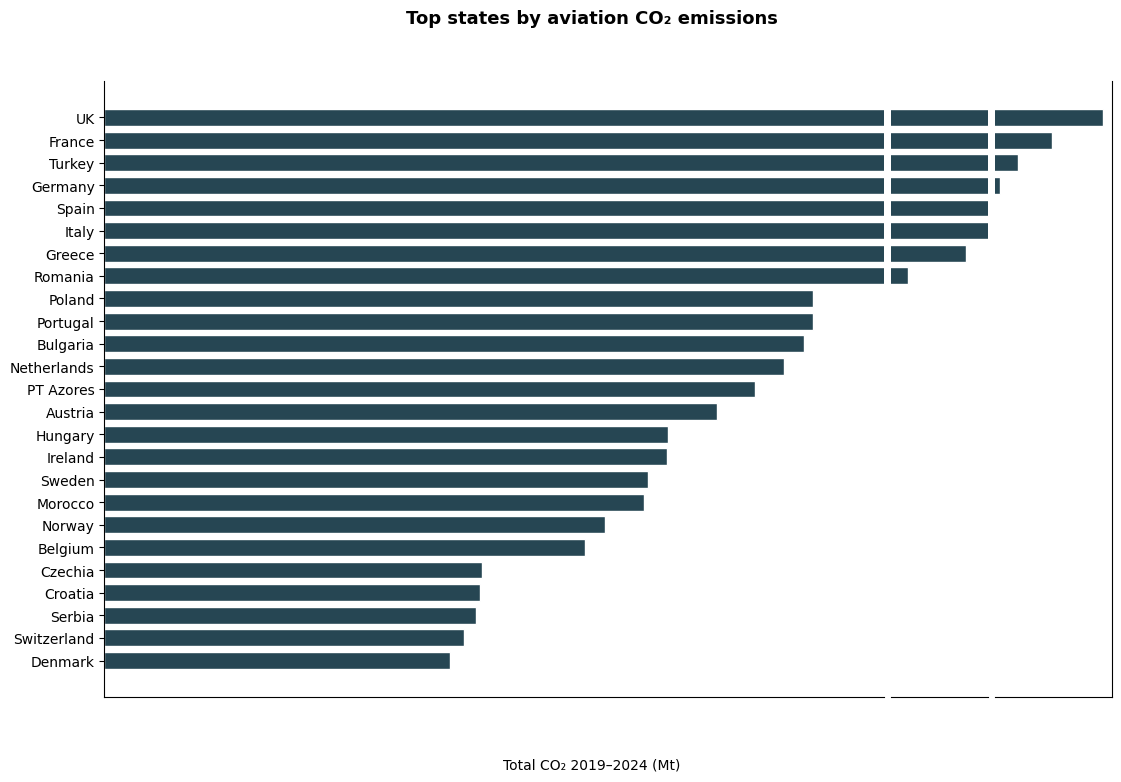

[Saved] blackhat_co2_broken_axis_v6.png


In [16]:
"""
BLACK HAT visualization — Broken axis CO₂ bar chart (v6)
=========================================================
- No value annotations on bars
- No break marks
- No x-axis tick values on any panel
- Most polluting at bottom
"""

import matplotlib.pyplot as plt
import numpy as np

# ── Data preparation ────────────────────────────────────────────────────────
state_tot = (
    df_state.groupby("AREA")["CO2_KG"].sum()
    .reset_index()
    .sort_values("CO2_KG", ascending=False)
    .head(25)
)
state_tot["name"] = state_tot["AREA"].map(CODE2NAME).fillna(state_tot["AREA"])

# Reverse order: smallest on top, biggest at bottom
state_tot = state_tot.iloc[::-1].reset_index(drop=True)

names = state_tot["name"].values
vals  = state_tot["CO2_KG"].values / 1e9  # Mt

# ── THREE-PANEL broken axis ────────────────────────────────────────────────
fig, (ax1, ax2, ax3) = plt.subplots(
    1, 3, sharey=True, figsize=(13, 8),
    gridspec_kw={
        "width_ratios": [4, 0.5, 0.6],
        "wspace": 0.02
    }
)

for ax in [ax1, ax2, ax3]:
    ax.barh(names, vals, color="#264653", edgecolor="white", height=0.75)

# Axis limits — two cuts
ax1.set_xlim(0, 22)
ax2.set_xlim(25, 35)
ax3.set_xlim(78, 122)

# Hide spines between panels
ax1.spines["right"].set_visible(False)
ax1.spines["top"].set_visible(False)

ax2.spines["left"].set_visible(False)
ax2.spines["right"].set_visible(False)
ax2.spines["top"].set_visible(False)
ax2.tick_params(left=False)

ax3.spines["left"].set_visible(False)
ax3.spines["top"].set_visible(False)
ax3.tick_params(left=False)

# Remove ALL x-axis ticks and labels from every panel
ax1.set_xticks([])
ax2.set_xticks([])
ax3.set_xticks([])

fig.text(0.5, 0.02, "Total CO₂ 2019–2024 (Mt)", ha="center", fontsize=10)
fig.suptitle("Top states by aviation CO₂ emissions",
             fontweight="bold", fontsize=13, y=0.97)

plt.tight_layout(rect=[0, 0.04, 1, 0.95])
plt.savefig("blackhat_co2_broken_axis_v6.png", dpi=150, bbox_inches="tight")
plt.show()
print("[Saved] blackhat_co2_broken_axis_v6.png")